In [1]:
import os, sys, time, math
import numpy as np
import torch
import matplotlib.pyplot as plt

# The file list shows model.py is directly in /content/
project_root = '/content'

sys.path.insert(0, project_root)
print('Project root:', project_root)

import model
from model import GPT, GPTConfig
print('Loaded successfully!')

Project root: /content
Loaded successfully!


### Device Configuration

In [3]:
device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda'
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = 'mps'
print(f"Using device: {device}")

Using device: cuda


### Data Loader setup
We define a function to grab a batch of data from the memory-mapped `.bin` files created during the dataset preparation phase.

In [ ]:
batch_size = 32 # number of independent sequences to process in parallel
block_size = 256 # maximum context length for predictions

def get_batch(split, dataset='poems'):
    data_dir = '/content'
    filename = f"{dataset}_{split}.bin"
    filepath = os.path.join(data_dir, filename)

    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Dataset file {filepath} not found.")

    data = np.memmap(filepath, dtype=np.uint16, mode='r')
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])

    if device == 'cuda':
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    return x, y

### Model Initialization

In [9]:
config = GPTConfig(
    block_size=block_size,
    vocab_size=50257,
    n_layer=8,
    n_head=8,
    n_embd=384,
    dropout=0.1
)

model = GPT(config)
model.to(device)
print(f"Model parameters: {model.get_num_params()/1e6:.2f} M")

number of parameters: 33.50M
Model parameters: 33.50 M


### Training Loop & Tracker

In [10]:
def estimate_loss(model, dataset='poems', eval_iters=50):
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split, dataset)
            with torch.no_grad():
                logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

def get_gpu_memory():
    if device == 'cuda':
        return torch.cuda.memory_allocated() / (1024**2) # MB
    elif device == 'mps':
        return torch.mps.current_allocated_memory() / (1024**2) # MB
    return 0.0

In [11]:
def train_model(model, dataset, max_iters=2000, eval_interval=200, learning_rate=1e-3):
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

    # Trackers
    history = {
        'iter': [],
        'train_loss': [],
        'val_loss': [],
        'gpu_mem_mb': [],
        'time_sec': []
    }

    start_time = time.time()
    print(f"\n--- Starting {dataset.upper()} training ---")

    for iter in range(max_iters):
        # Every once in a while evaluate the loss on train and val sets
        if iter % eval_interval == 0 or iter == max_iters - 1:
            losses = estimate_loss(model, dataset)
            gpu_mem = get_gpu_memory()
            elapsed = time.time() - start_time

            history['iter'].append(iter)
            history['train_loss'].append(losses['train'])
            history['val_loss'].append(losses['val'])
            history['gpu_mem_mb'].append(gpu_mem)
            history['time_sec'].append(elapsed)

            print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f} | GPU Mem: {gpu_mem:.1f} MB | Time: {elapsed:.1f}s")

        # Sample a batch of data
        xb, yb = get_batch('train', dataset)

        # Evaluate the loss
        logits, loss = model(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

    return history

### Pretraining on Poems

In [12]:
poem_history = train_model(model, dataset='poems', max_iters=2000, eval_interval=250, learning_rate=1e-3)


--- Starting POEMS training ---
step 0: train loss 10.8751, val loss 10.8703 | GPU Mem: 2428.9 MB | Time: 23.6s
step 250: train loss 5.7691, val loss 5.9911 | GPU Mem: 4389.0 MB | Time: 209.3s
step 500: train loss 5.4677, val loss 5.7573 | GPU Mem: 4387.6 MB | Time: 396.2s
step 750: train loss 5.2919, val loss 5.6043 | GPU Mem: 4388.7 MB | Time: 582.5s
step 1000: train loss 5.0826, val loss 5.4834 | GPU Mem: 4387.5 MB | Time: 768.8s
step 1250: train loss 4.9833, val loss 5.3666 | GPU Mem: 4388.9 MB | Time: 955.7s
step 1500: train loss 4.8274, val loss 5.2445 | GPU Mem: 4388.7 MB | Time: 1142.1s
step 1750: train loss 4.7185, val loss 5.1725 | GPU Mem: 4388.7 MB | Time: 1328.6s
step 1999: train loss 4.6080, val loss 5.0492 | GPU Mem: 4387.3 MB | Time: 1514.4s


### Fine-Tuning on Raps

In [13]:
rap_history = train_model(model, dataset='raps', max_iters=2000, eval_interval=250, learning_rate=3e-4)


--- Starting RAPS training ---
step 0: train loss 5.7061, val loss 5.7353 | GPU Mem: 2560.1 MB | Time: 22.7s
step 250: train loss 4.1190, val loss 4.6193 | GPU Mem: 4388.2 MB | Time: 210.4s
step 500: train loss 3.8926, val loss 4.5035 | GPU Mem: 4387.3 MB | Time: 397.2s
step 750: train loss 3.7401, val loss 4.4666 | GPU Mem: 4388.2 MB | Time: 583.5s
step 1000: train loss 3.5694, val loss 4.4077 | GPU Mem: 4387.1 MB | Time: 771.2s
step 1250: train loss 3.4401, val loss 4.3821 | GPU Mem: 4388.4 MB | Time: 958.2s
step 1500: train loss 3.3237, val loss 4.3863 | GPU Mem: 4386.1 MB | Time: 1145.6s
step 1750: train loss 3.2212, val loss 4.3241 | GPU Mem: 4388.7 MB | Time: 1332.7s
step 1999: train loss 3.1539, val loss 4.3658 | GPU Mem: 4390.9 MB | Time: 1519.6s


### Visualization of Training Progress

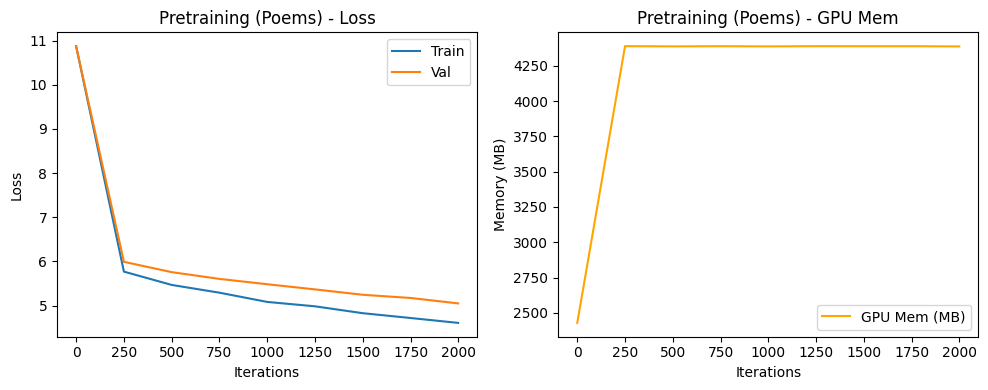

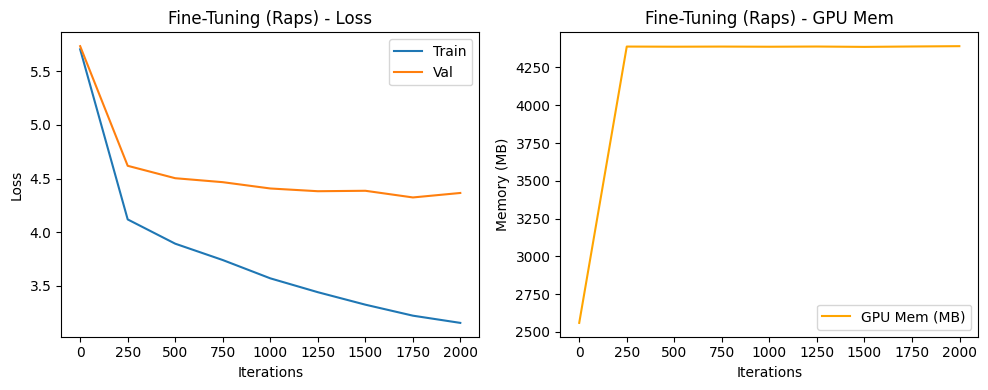

In [14]:
def plot_history(history, title):
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history['iter'], history['train_loss'], label='Train')
    plt.plot(history['iter'], history['val_loss'], label='Val')
    plt.xlabel('Iterations')
    plt.ylabel('Loss')
    plt.title(f"{title} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['iter'], history['gpu_mem_mb'], label='GPU Mem (MB)', color='orange')
    plt.xlabel('Iterations')
    plt.ylabel('Memory (MB)')
    plt.title(f"{title} - GPU Mem")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(poem_history, "Pretraining (Poems)")
plot_history(rap_history, "Fine-Tuning (Raps)")

### Save the Model

In [15]:
checkpoint = {
    'model': model.state_dict(),
    'config': config,
}
torch.save(checkpoint, 'nanogpt_checkpoint.pt')
print("Model saved to nanogpt_checkpoint.pt")

Model saved to nanogpt_checkpoint.pt
